# Tutorial: Analyzing GAE Training Logs

## Learning Objectives

By the end of this tutorial, you will be able to:

1. **Load and parse GAE training logs** from saved log files
2. **Understand GAE metrics** including F1 scores, balanced accuracy, and reconstruction losses
3. **Visualize training progress** with raw and smoothed metric plots
4. **Identify training issues** such as overfitting, underfitting, and convergence problems
5. **Interpret metric trends** to assess model quality
6. **Make hyperparameter adjustments** based on log analysis

## Table of Contents

- [1. Introduction to GAE Training Logs](#1-introduction-to-gae-training-logs)
  
- [2. Setup and Imports](#2-setup-and-imports)
  
- [3. Loading Log Files](#3-loading-log-files)
  
- [4. Understanding GAE Metrics](#4-understanding-gae-metrics)
  
- [5. Parsing Log Data](#5-parsing-log-data)
  
- [6. Visualizing Training Metrics](#6-visualizing-training-metrics)
  
- [7. Interpreting Metric Trends](#7-interpreting-metric-trends)
  
- [8. Identifying Training Issues](#8-identifying-training-issues)
  
- [9. Hyperparameter Tuning Guidance](#9-hyperparameter-tuning-guidance)
  
- [10. Summary and Next Steps](#10-summary-and-next-steps)

---

## 1. Introduction to GAE Training Logs

When training the **Graph Autoencoder (GAE)** for molecular fragment embeddings, the `GraphAutoencoderTrainer` saves detailed training logs that track:

- **Reconstruction losses**: How well the decoder reconstructs atom features, edge features, and adjacency matrices
- **Classification metrics**: F1 scores and balanced accuracy for atom/edge type predictions
- **Regression metrics**: R^2 scores for predicting atom/edge counts

These logs are crucial for:
- **Monitoring training progress**: Are metrics improving?
- **Detecting overfitting**: Is validation performance degrading while training improves?
- **Choosing checkpoints**: Which epoch produced the best embeddings?
- **Debugging failures**: Why isn't the model learning?

**Typical log file location**: `03_GAE/train_GAE_v5_vocab.log` (created automatically during training)

---

## 2. Setup and Imports

We'll use:
- **GSGE's built-in log parser**: `parse_log_file()` extracts metrics from log text
- **Matplotlib/Seaborn**: For publication-quality plots
- **Scipy's Gaussian filter**: For smoothing noisy metric curves

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from pathlib import Path

# GSGE log parsing utility
from GSGE.graphs.fragment_graph.parsed_log_metric_plots import parse_log_file

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 14})

print("[OK] Imports successful")

[OK] Imports successful


---

## 3. Loading Log Files

**Option 1: Use your own log file**

If you've trained a GAE model, you'll have a log file in your checkpoint directory:

```python
log_path = Path("03_GAE/train_GAE_v5_vocab.log")  # Replace with your path
```

**Option 2: Generate a new log file**

If you don't have a log file, run the GAE training tutorial first:
- See `use_examples/GAE/train_GAE_v2.ipynb`
- The trainer automatically creates log files during training

For this tutorial, we'll assume you have a log file. Update the path below to your actual log file location:

In [6]:
# UPDATE THIS PATH to your actual log file
log_path = Path("train_GAE_v5_vocab.log")

# Check if file exists
if not log_path.exists():
    raise FileNotFoundError(
        f"Log file not found at {log_path}\n"
        f"Please update the path to your actual log file, or run GAE training first."
    )

# Read log file (use UTF-8 encoding for cross-platform compatibility)
with open(log_path, 'r', encoding='utf-8') as f:
    log_text = f.read()

print(f"[OK] Loaded log file: {log_path}")
print(f"  Log size: {len(log_text):,} characters")
print(f"  First 500 characters:")
print(log_text[:500])

[OK] Loaded log file: train_GAE_v5_vocab.log
  Log size: 308,101 characters
  First 500 characters:
nohup: ignoring input
Loading vocabulary...
Vocabulary loaded successfully!

100%|██████████| 185/185 [00:00<00:00, 1184.51it/s]
Loading corpus...
Vocabulary loaded successfully!

  4%|▍         | 378/8771 [00:00<00:06, 1238.05it/s]
  6%|▌         | 505/8771 [0


---

## 4. Understanding GAE Metrics

The GAE training logs track multiple metrics for both **training** and **validation** sets:

### Reconstruction Losses

1. **Atom Loss**: CrossEntropyLoss for predicting atom types (C, N, O, etc.)
   - Lower is better
   - Should decrease steadily during training

2. **Edge Loss**: CrossEntropyLoss for predicting bond types (single, double, aromatic)
   - Lower is better
   - Often harder to minimize than atom loss

3. **Total Loss**: Weighted sum of atom loss + edge loss + adjacency loss
   - Primary optimization target

### Classification Metrics

1. **Atom F1 Score** (`atom_f1`): F1 score for atom type predictions
   - Range: 0.0 to 1.0 (higher is better)
   - Good models achieve >0.90

2. **Edge Type F1** (`edge_type_f1`): F1 score for bond type predictions
   - Range: 0.0 to 1.0 (higher is better)
   - Good models achieve >0.85

3. **Adjacency F1** (`adj_f1`): F1 score for predicting which atoms are bonded
   - Range: 0.0 to 1.0 (higher is better)
   - Good models achieve >0.92

### Balanced Accuracy

1. **Balanced Atom Accuracy** (`balanced_atom_acc`): Accounts for class imbalance in atom types
   - More reliable than raw accuracy when some atom types are rare

2. **Balanced Edge Type Accuracy** (`balanced_edge_type_acc`)
3. **Balanced Adjacency Accuracy** (`balanced_adj_acc`)

### Regression Metrics

1. **Atom Number R^2** (`atom_num_r2`): How well the model predicts total atom count
2. **Edge Number R^2** (`edge_num_r2`): How well the model predicts total bond count

**Key insight**: We focus on **F1 scores** and **balanced accuracy** because they're most informative for evaluating reconstruction quality.

---

## 5. Parsing Log Data

The `parse_log_file()` function extracts all metrics from the log text and organizes them by epoch:

```python
data = {
    1: {"Train_atom_f1": [0.85], "Val_atom_f1": [0.82], ...},
    2: {"Train_atom_f1": [0.87], "Val_atom_f1": [0.84], ...},
    ...
}
```

Each epoch contains Train/Val versions of all metrics.

In [7]:
# Parse log text
data = parse_log_file(log_text)

# Inspect parsed data
epochs = sorted(data.keys())
print(f"[OK] Parsed {len(epochs)} epochs of training data")
print(f"  Epoch range: {min(epochs)} to {max(epochs)}")
print(f"\nMetrics available in epoch {epochs[0]}:")
for key in sorted(data[epochs[0]].keys())[:10]:  # Show first 10 metrics
    print(f"  - {key}: {data[epochs[0]][key]}")

[OK] Parsed 301 epochs of training data
  Epoch range: 1 to 301

Metrics available in epoch 1:
  - Train_Atom Loss: [167.0284]
  - Train_Edge Loss: [134.5412]
  - Train_Total Loss: [301.5696]
  - Train_adj_accuracy: [0.8368]
  - Train_adj_f1: [0.768]
  - Train_atom_accuracy: [0.5809]
  - Train_atom_f1: [0.0834]
  - Train_atom_num_r2: [0.7412]
  - Train_balanced_adj_acc: [0.8119]
  - Train_balanced_atom_acc: [0.093]


---

## 6. Visualizing Training Metrics

We'll create two types of plots:

1. **Raw + Smoothed Plots**: Show actual epoch values (scatter) + Gaussian-smoothed trend lines
   - Solid lines = Training metrics
   - Dashed lines = Validation metrics
   - Light scatter points = Raw epoch values

2. **Side-by-Side Comparison**: F1 Scores vs. Balanced Accuracy

### Custom Plotting Function

This function plots any metric group with customizable smoothing:

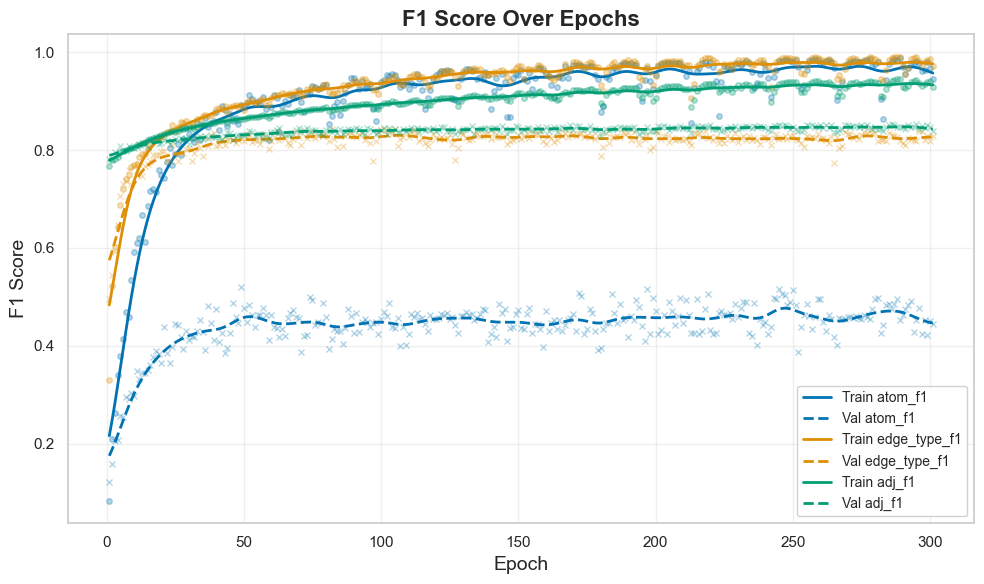

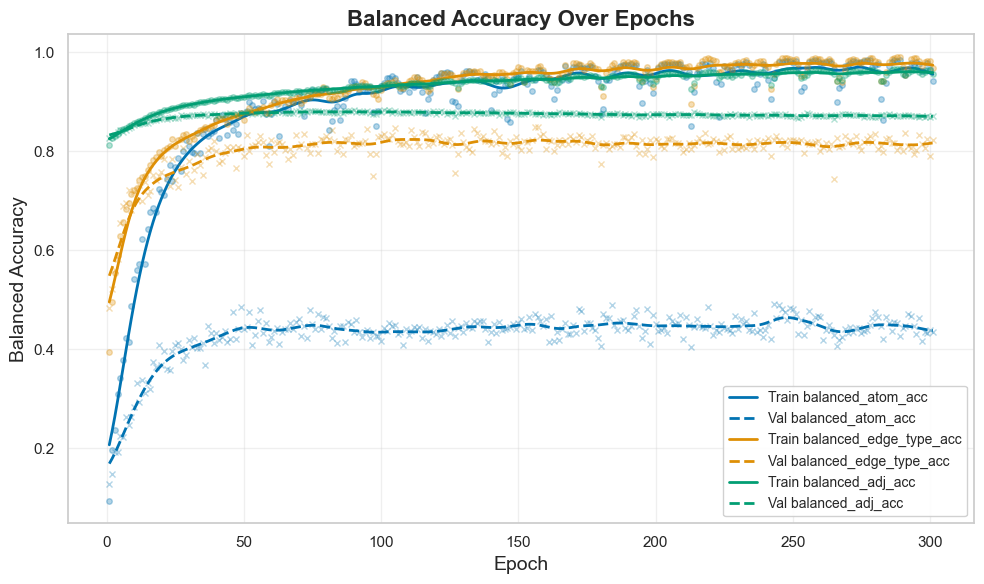

In [8]:
def plot_metrics(data, smooth_sigma=1.5):
    """
    Plot GAE training metrics with raw scatter + smoothed trend lines.
    
    Parameters
    ----------
    data : dict
        Parsed log data from parse_log_file()
    smooth_sigma : float
        Gaussian smoothing parameter. Higher = smoother curves.
        Recommended: 1.5 for <50 epochs, 5-10 for 100+ epochs
    """
    sns.set(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    epochs = sorted(data.keys())
    
    # Define metric groups to plot
    metric_groups = {
        "F1 Score": ["atom_f1", "edge_type_f1", "adj_f1"],
        "Balanced Accuracy": ["balanced_atom_acc", "balanced_edge_type_acc", "balanced_adj_acc"],
    }

    # Colorblind-safe palette
    base_colors = sns.color_palette("colorblind", 6)

    for group_name, metrics in metric_groups.items():
        plt.figure(figsize=(10, 6))
        has_data = False
        
        for i, metric in enumerate(metrics):
            color = base_colors[i % len(base_colors)]
            train_key = f"Train_{metric}"
            val_key = f"Val_{metric}"
            train_values, val_values = [], []

            # Extract values for each epoch
            for e in epochs:
                train_val = data[e].get(train_key, [np.nan])[0]
                val_val = data[e].get(val_key, [np.nan])[0]
                train_values.append(train_val)
                val_values.append(val_val)
            
            train_values = np.array(train_values)
            val_values = np.array(val_values)

            if not np.all(np.isnan(train_values)) or not np.all(np.isnan(val_values)):
                has_data = True

                # Apply Gaussian smoothing
                smoothed_train = gaussian_filter1d(train_values, sigma=smooth_sigma, mode='nearest')
                smoothed_val = gaussian_filter1d(val_values, sigma=smooth_sigma, mode='nearest')

                # Plot raw scatter (light alpha)
                plt.plot(epochs, train_values, 'o', color=color, alpha=0.3, markersize=4)
                plt.plot(epochs, val_values, 'x', color=color, alpha=0.3, markersize=5)

                # Plot smoothed lines (Train=solid, Val=dashed)
                plt.plot(epochs, smoothed_train, '-', color=color, linewidth=2, label=f"Train {metric}")
                plt.plot(epochs, smoothed_val, '--', color=color, linewidth=2, label=f"Val {metric}")
        
        if has_data:
            plt.title(f"{group_name} Over Epochs", fontsize=16, fontweight='bold')
            plt.xlabel("Epoch", fontsize=14)
            plt.ylabel(group_name, fontsize=14)
            plt.legend(loc='best', fontsize=10, framealpha=0.9)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"[!] No data to plot for {group_name}")
            plt.close()


# Plot with moderate smoothing
plot_metrics(data, smooth_sigma=5)

---

## 7. Interpreting Metric Trends

### What to Look For:

#### 1. **Healthy Training** [OK]
- **Train and Val both increase**: Model is learning generalizable patterns
- **Val plateaus near Train**: Model has reached capacity (increase model size or train longer)
- **Val slightly below Train**: Normal, indicates some overfitting (acceptable)

#### 2. **Overfitting** [!]
- **Train increases, Val decreases**: Classic overfitting
- **Large Train-Val gap** (>0.1 for F1 scores): Model memorizing training data
- **Solutions**:
  - Increase dropout (try 0.2-0.4)
  - Add more training data (expand corpus)
  - Reduce model size (fewer layers/hidden dim)
  - Stop training earlier (use best Val checkpoint)

#### 3. **Underfitting** [!]
- **Both Train and Val are low** (<0.7 F1 score)
- **Both still increasing steadily**: Train longer
- **Solutions**:
  - Increase model capacity (more layers, larger hidden_dim)
  - Train for more epochs
  - Reduce regularization (lower dropout)
  - Check learning rate (may be too low)

#### 4. **Noisy/Unstable Training** [!]
- **Large oscillations** in validation metrics
- **Metrics jump up and down**
- **Solutions**:
  - Reduce learning rate
  - Increase batch size
  - Add gradient clipping
  - Use learning rate scheduling

### Side-by-Side Comparison Plot

Let's create a publication-quality figure comparing F1 scores and balanced accuracy:

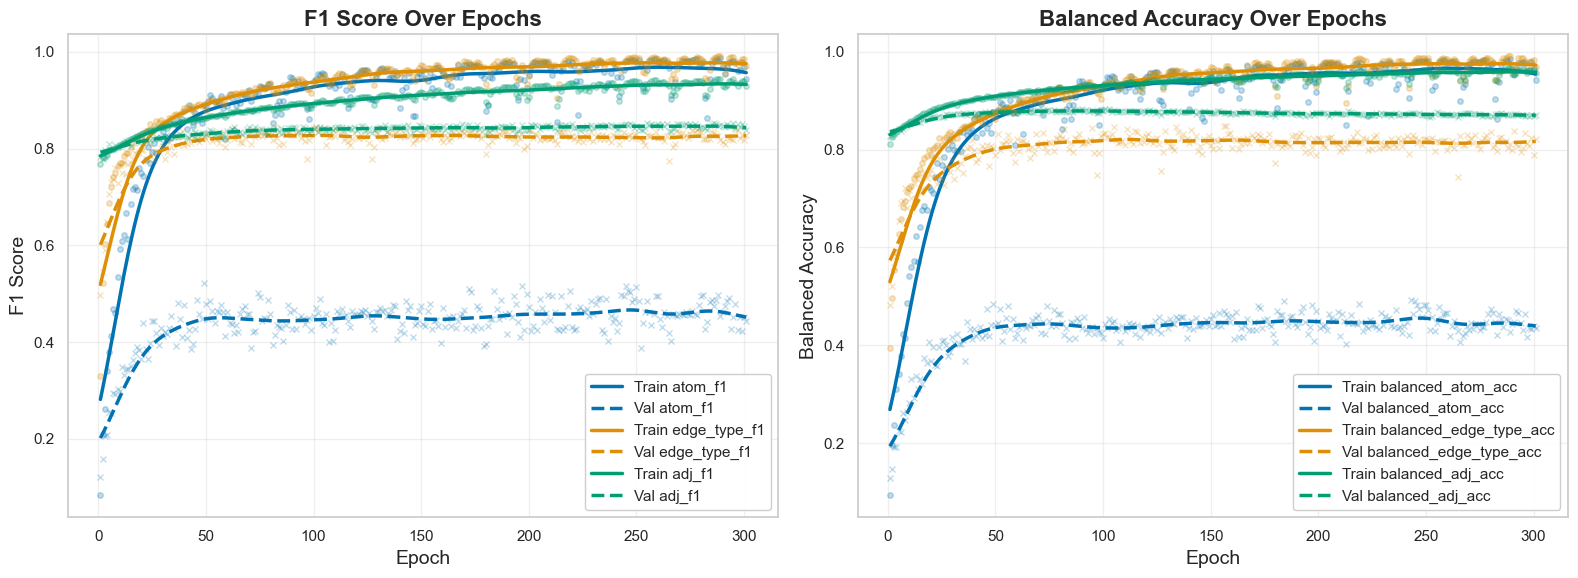

In [9]:
def plot_metrics_sidebyside(data, smooth_sigma=5):
    """
    Plot F1 Score and Balanced Accuracy side-by-side for comparison.
    """
    sns.set(style="whitegrid")
    plt.rcParams.update({'font.size': 14})
    
    epochs = sorted(data.keys())
    metric_groups = {
        "F1 Score": ["atom_f1", "edge_type_f1", "adj_f1"],
        "Balanced Accuracy": ["balanced_atom_acc", "balanced_edge_type_acc", "balanced_adj_acc"]
    }

    base_colors = sns.color_palette("colorblind", 6)

    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)

    axes = [ax1, ax2]
    for ax, (group_name, metrics) in zip(axes, metric_groups.items()):
        has_data = False
        
        for i, metric in enumerate(metrics):
            color = base_colors[i % len(base_colors)]
            train_key = f"Train_{metric}"
            val_key = f"Val_{metric}"
            train_values, val_values = [], []

            for e in epochs:
                train_val = data[e].get(train_key, [np.nan])[0]
                val_val = data[e].get(val_key, [np.nan])[0]
                train_values.append(train_val)
                val_values.append(val_val)
            
            train_values = np.array(train_values)
            val_values = np.array(val_values)

            if not np.all(np.isnan(train_values)) or not np.all(np.isnan(val_values)):
                has_data = True

                # Smoothed versions
                smoothed_train = gaussian_filter1d(train_values, sigma=smooth_sigma, mode='nearest')
                smoothed_val = gaussian_filter1d(val_values, sigma=smooth_sigma, mode='nearest')

                # Raw scatter
                ax.plot(epochs, train_values, 'o', color=color, alpha=0.25, markersize=4)
                ax.plot(epochs, val_values, 'x', color=color, alpha=0.25, markersize=5)

                # Smoothed lines
                ax.plot(epochs, smoothed_train, '-', color=color, linewidth=2.5, label=f"Train {metric}")
                ax.plot(epochs, smoothed_val, '--', color=color, linewidth=2.5, label=f"Val {metric}")
        
        if has_data:
            ax.set_title(f"{group_name} Over Epochs", fontsize=16, fontweight='bold')
            ax.set_xlabel("Epoch", fontsize=14)
            ax.set_ylabel(group_name, fontsize=14)
            ax.legend(loc='best', fontsize=11, framealpha=0.95)
            ax.grid(alpha=0.3)
        else:
            print(f"[!] No data to plot for {group_name}")
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()


# Create comparison plot with heavy smoothing
plot_metrics_sidebyside(data, smooth_sigma=10)

---

## 8. Identifying Training Issues

Let's programmatically detect common training issues:

In [10]:
def analyze_training(data, metric="atom_f1", window=10):
    """
    Analyze training health by detecting common issues.
    
    Parameters
    ----------
    data : dict
        Parsed log data
    metric : str
        Metric to analyze (e.g., "atom_f1", "edge_type_f1")
    window : int
        Number of recent epochs to analyze
    """
    epochs = sorted(data.keys())
    train_key = f"Train_{metric}"
    val_key = f"Val_{metric}"
    
    # Extract values
    train_vals = [data[e].get(train_key, [np.nan])[0] for e in epochs]
    val_vals = [data[e].get(val_key, [np.nan])[0] for e in epochs]
    
    train_vals = np.array(train_vals)
    val_vals = np.array(val_vals)
    
    # Get recent epochs for analysis
    recent_train = train_vals[-window:]
    recent_val = val_vals[-window:]
    
    print(f"\n=== Training Analysis for {metric} ===")
    print(f"Analyzing last {window} epochs (epochs {epochs[-window]}-{epochs[-1]})\n")
    
    # 1. Best scores achieved
    print(f"[OK] Best Scores:")
    print(f"  Train: {np.nanmax(train_vals):.4f} (epoch {epochs[np.nanargmax(train_vals)]})")
    print(f"  Val:   {np.nanmax(val_vals):.4f} (epoch {epochs[np.nanargmax(val_vals)]})")
    
    # 2. Current scores
    print(f"\n[OK] Current Scores (epoch {epochs[-1]}):")
    print(f"  Train: {train_vals[-1]:.4f}")
    print(f"  Val:   {val_vals[-1]:.4f}")
    
    # 3. Train-Val gap
    gap = train_vals[-1] - val_vals[-1]
    print(f"\n[OK] Train-Val Gap: {gap:.4f}")
    if gap > 0.15:
        print(f"  [!] WARNING: Large gap suggests overfitting!")
        print(f"     -> Try: increase dropout, add more data, reduce model size")
    elif gap > 0.05:
        print(f"  [OK] Moderate gap (normal)")
    else:
        print(f"  [OK] Small gap (excellent generalization)")
    
    # 4. Recent trends
    train_trend = np.mean(np.diff(recent_train))
    val_trend = np.mean(np.diff(recent_val))
    
    print(f"\n[OK] Recent Trends (last {window} epochs):")
    print(f"  Train: {'+' if train_trend > 0 else ''}{train_trend:.5f} per epoch")
    print(f"  Val:   {'+' if val_trend > 0 else ''}{val_trend:.5f} per epoch")
    
    if train_trend > 0.001 and val_trend > 0.001:
        print(f"  [OK] Both improving - continue training")
    elif train_trend > 0.001 and val_trend < -0.001:
        print(f"  [!] WARNING: Overfitting detected!")
        print(f"     -> Stop training and use earlier checkpoint")
    elif abs(train_trend) < 0.0005 and abs(val_trend) < 0.0005:
        print(f"  [OK] Converged - training can be stopped")
    else:
        print(f"  -> Training still in progress")
    
    # 5. Stability
    val_std = np.std(recent_val)
    print(f"\n[OK] Validation Stability (std dev): {val_std:.4f}")
    if val_std > 0.05:
        print(f"  [!] High variance - consider reducing learning rate or increasing batch size")
    else:
        print(f"  [OK] Stable training")


# Analyze key metrics
analyze_training(data, metric="atom_f1", window=20)
analyze_training(data, metric="adj_f1", window=20)


=== Training Analysis for atom_f1 ===
Analyzing last 20 epochs (epochs 282-301)

[OK] Best Scores:
  Train: 0.9869 (epoch 289)
  Val:   0.5213 (epoch 49)

[OK] Current Scores (epoch 301):
  Train: 0.9448
  Val:   0.4446

[OK] Train-Val Gap: 0.5002
  [!] WARNING: Large gap suggests overfitting!
     -> Try: increase dropout, add more data, reduce model size

[OK] Recent Trends (last 20 epochs):
  Train: +0.00211 per epoch
  Val:   +0.00092 per epoch
  -> Training still in progress

[OK] Validation Stability (std dev): 0.0236
  [OK] Stable training

=== Training Analysis for adj_f1 ===
Analyzing last 20 epochs (epochs 282-301)

[OK] Best Scores:
  Train: 0.9446 (epoch 289)
  Val:   0.8530 (epoch 295)

[OK] Current Scores (epoch 301):
  Train: 0.9295
  Val:   0.8386

[OK] Train-Val Gap: 0.0909
  [OK] Moderate gap (normal)

[OK] Recent Trends (last 20 epochs):
  Train: +0.00099 per epoch
  Val:   -0.00021 per epoch
  -> Training still in progress

[OK] Validation Stability (std dev): 0.00

---

## 9. Hyperparameter Tuning Guidance

Based on your log analysis, here's how to adjust hyperparameters:

### If Overfitting (Train-Val gap >0.15):

```python
# In your GAE training script:

# 1. Increase dropout
encoder = AttentiveFP(
    ...,
    dropout=0.3  # Up from 0.1
)

# 2. Reduce model size
encoder = AttentiveFP(
    hidden_channels=128,  # Down from 256
    num_layers=2          # Down from 3
)

# 3. Add more training data
corpus.build_corpus(
    expanded_smiles_list,  # More molecules
    ...
)
```

### If Underfitting (Val F1 <0.7):

```python
# 1. Increase model capacity
encoder = AttentiveFP(
    hidden_channels=512,  # Up from 256
    num_layers=4,         # Up from 3
    num_timesteps=3       # Up from 2
)

# 2. Train longer
trainer.train(num_epochs=500)  # Up from 300

# 3. Reduce dropout
encoder = AttentiveFP(
    ...,
    dropout=0.05  # Down from 0.2
)
```

### If Unstable (High variance):

```python
# 1. Reduce learning rate
optimizer = torch.optim.Adam(
    params,
    lr=0.0001  # Down from 0.001
)

# 2. Increase batch size
train_loader = DataLoader(
    dataset,
    batch_size=128,  # Up from 64
    ...
)

# 3. Add gradient clipping
torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
```

### If Converged:

- **Use the best validation checkpoint** (not the final epoch)
- Load embeddings from the epoch with highest Val F1 score
- Save those embeddings for downstream tasks

---

## 10. Summary and Next Steps

### What We Learned

1. [OK] **Loaded and parsed GAE training logs** using `parse_log_file()`
2. [OK] **Understood GAE metrics**: F1 scores, balanced accuracy, and their meanings
3. [OK] **Visualized training progress** with raw + smoothed plots
4. [OK] **Interpreted metric trends** to assess model quality
5. [OK] **Identified training issues** (overfitting, underfitting, instability)
6. [OK] **Applied hyperparameter tuning** based on log analysis

### Key Takeaways

- **Always monitor both Train and Val metrics** - the gap tells the story
- **F1 scores >0.9** indicate high-quality fragment embeddings
- **Use smoothing** to see trends through noise (sigma=5-10 for 100+ epochs)
- **Select checkpoints by Val F1**, not Train F1 or final epoch
- **Iterate on hyperparameters** based on systematic log analysis

### Next Steps

1. **If training is ongoing**: Continue monitoring logs and adjust hyperparameters as needed

2. **If training is complete**: Load the best checkpoint and extract embeddings:
   ```python
   from GSGE import GSGE
   
   gsge = GSGE(GS_vocab='vocab.pkl')
   gsge.set_encoder()
   gsge.load_GAE_weights('checkpoints/checkpoint_epoch_100.pth')  # Best Val epoch
   gsge.make_GS_fragment_embedding_dict()
   ```

3. **Visualize learned embeddings**: See `clustering_vocab_in_fragment_corpus_space.ipynb`

4. **Use embeddings in downstream models**: See `use_embeddings/` tutorials

5. **Export embeddings for external tools**:
   ```python
   gsge.save_gsge_data('gsge_with_embeddings.pkl')
   ```

### Troubleshooting

- **Log file not found**: Make sure you've run GAE training first (see `train_GAE_v2.ipynb`)
- **Metrics all NaN**: Check log file format - it should contain lines like "Epoch X/Y, Train_atom_f1: 0.XXX"
- **No plots showing**: Verify that parsed data contains the expected metric keys

---

**Congratulations!** You can now analyze GAE training logs like a pro. [DONE]